## Algorithm (1D mono-energetic diffusion, bare + reflected slab)

### Geometry and data
- Model only the **right half** of the system by symmetry.
- Core thickness: $2a = 40\,\mathrm{cm}$  $\Rightarrow$  $a = 20\,\mathrm{cm}$.
- Reflector thickness: $b = 10\,\mathrm{cm}$.
- Spatial domain:
  - **Bare core:** $x \in [0, a]$
  - **Reflected core:** $x \in [0, a+b]$
- Uniform mesh: $\Delta x = 0.1\,\mathrm{cm}$, unknowns are cell-centered flux values $\{\phi_i\}$, $i=1,\dots,N$.

### Governing equation 
Use the 1-group diffusion eigenvalue form written with self-scattering on both sides:
$$
\frac{d}{dx}\!\left(D(x)\frac{d\phi}{dx}\right) + \big(\Sigma_a(x)+\Sigma_s(x)\big)\phi(x)
=
\frac{1}{k}\,\nu\Sigma_f(x)\phi(x) + \Sigma_s(x)\phi(x).
$$

Notes:
- In the **core**: $\nu\Sigma_f > 0$.
- In the **reflector**: $\nu\Sigma_f = 0$.
- Diffusion coefficient:
$$
D(x)=\frac{1}{3\Sigma_t(x)},\qquad \Sigma_t(x)=\Sigma_a(x)+\Sigma_s(x).
$$

### Finite-difference discretization (tridiagonal system)
- Use a conservative 1D discretization with face diffusion coefficients:
$$
D_{i+\frac12} = \text{harmonic mean}(D_i, D_{i+1}).
$$

- Interior node $i=2,\dots,N-1$:
$$
-\frac{D_{i-\frac12}}{\Delta x^2}\phi_{i-1}
+\left(\frac{D_{i-\frac12}+D_{i+\frac12}}{\Delta x^2}+\Sigma_{a,i}+\Sigma_{s,i}\right)\phi_i
-\frac{D_{i+\frac12}}{\Delta x^2}\phi_{i+1}
=
\frac{1}{k}\nu\Sigma_{f,i}\phi_i+\Sigma_{s,i}\phi_i.
$$

This is written at each power-iteration step as:
$$
A\,\phi^{(n+1)}=\frac{1}{k^{(n)}}F\,\phi^{(n)}+S\,\phi^{(n)},
$$
where $F=\mathrm{diag}(\nu\Sigma_f)$ and $S=\mathrm{diag}(\Sigma_s)$.

### Boundary conditions
- Left boundary (symmetry at $x=0$): reflective
$$
\left.\frac{d\phi}{dx}\right|_{x=0}=0 \quad \Rightarrow \quad \phi_0=\phi_1.
$$

- Right boundary: vacuum (zero incoming partial current)
$$
J^{-}(x_{\max})=0,\qquad J^{-}=\frac{\phi}{4}+D\frac{d\phi}{dx}.
$$
This provides the closure relation used to build the last row of the linear system.

### Power iteration for $k$
1. Initialize $k^{(0)}=1$ and $\phi^{(0)}$ as a positive vector (e.g., uniform).
2. For $n=0,1,2,\dots$ until convergence:
   - Build the RHS source:
     $$
     q^{(n)}=\frac{1}{k^{(n)}}F\,\phi^{(n)}+S\,\phi^{(n)}.
     $$
   - Solve:
     $$
     A\,\phi^{(n+1)}=q^{(n)}
     $$
     (using the existing linear solver, e.g. SOR / tridiagonal solver).
   - Update $k$ using the fission-source ratio:
     $$
     k^{(n+1)} = k^{(n)}
     \frac{\sum_i \nu\Sigma_{f,i}\phi^{(n+1)}_i\,\Delta x}{\sum_i \nu\Sigma_{f,i}\phi^{(n)}_i\,\Delta x}.
     $$
   - Normalize for plotting:
     $$
     \phi^{(n+1)} \leftarrow \frac{\phi^{(n+1)}}{\phi^{(n+1)}(x=0)}.
     $$
   - Stop when $|k^{(n+1)}-k^{(n)}|<10^{-7}$.

### Post-processing (requested outputs)
- Flux plots:
  - Bare reactor: plot normalized $\phi(x)$ on $x\in[0,a]$.
  - Reflected reactor: plot normalized $\phi(x)$ on $x\in[0,a+b]$.

- Net current at the core boundary $x=a$:
$$
J(a)=-D_{a+\frac12}\frac{\phi_{i+1}-\phi_i}{\Delta x},
$$
where $i$ is the last core node.

- Analytical comparison (bare reactor):
  Use cosine-shaped analytical solution normalized to $\phi(0)=1$:
$$
\phi_{\mathrm{ana}}(x)=\cos(Bx),\qquad B^2=\frac{\nu\Sigma_f/k-\Sigma_a}{D}.
$$
Plot the pointwise distance:
$$
e_i=\left|\phi_{\mathrm{num},i}-\phi_{\mathrm{ana}}(x_i)\right|.
$$


In [1]:
# =============================================
#Q1-find Keff and J at the left and right boundaries numericaly, only consider the bare core (no reflectors)
# =============================================
import numpy as np

# -----------------------------
# 0) Problem data
# -----------------------------
L  = 20.0        # cm (half slab: we model only the RHS)
dx = 0.1         # cm
N  = int(L/dx)   # grid points: 1..N

Sigma_a    = 0.01     # 1/cm
Sigma_s    = 0.30     # 1/cm
nuSigma_f  = 0.015    # 1/cm

Sigma_t = Sigma_a + Sigma_s
D       = 1.0/(3.0*Sigma_t)   # cm (P1 diffusion coefficient)

# -----------------------------
# 1) Show the three discrete equations we will use
# -----------------------------
print("== Continuous 1-group diffusion (steady) ==")
print("  -D * d2phi/dx2  +  Σ_a * phi  =  (νΣ_f / k) * phi")

print("\n== INTERIOR (i = 2..N-1) ==")       
print("  φ''_i ≈ (φ_{i+1} - 2φ_i + φ_{i-1}) / Δx²") #Aplying finite derivative method
print("  ⇒  - D/Δx² · φ_{i-1} + (2D/Δx² + Σ_a) φ_i - D/Δx² · φ_{i+1} = (νΣ_f/k) φ_i")

print("\n== LEFT boundary (reflective: ∂φ/∂x = 0 at x=0) ==") #Aplying the left boundary condition (reflective BC)
print("   φ_0 = φ_1  ⇒  φ''_1 ≈ (φ_2 - 2φ_1 + φ_0)/Δx² = (φ_2 - φ_1)/Δx²")
print("  ⇒  -D*(φ_2 - φ_1)/Δx² + Σ_a φ_1 = (νΣ_f/k) φ_1")
print("  ⇒  ( D/Δx² + Σ_a ) φ_1  -  ( D/Δx² ) φ_2  =  (νΣ_f/k) φ_1   (row 1)")

print("\n== RIGHT boundary (vacuum: φ + 2D ∂φ/∂x = 0 at x=L) ==") #Aplying the right boundary condition (vacuum BC)
print("    ∂φ/∂x|_L ≈ (φ_N - φ_{N-1})/Δx")
print("  ⇒  (1 + 2D/Δx) φ_N  -  (2D/Δx) φ_{N-1}  =  0   (row N)")

# -----------------------------
# 2) Build A and F for A φ = (1/k) F φ
#    Store tridiagonal bands: a (sub), b (diag), c (super)
# -----------------------------
#We create a empty matrix, with 3 diagonals
a = np.zeros(N)   # subdiagonal
b = np.zeros(N)   # diagonal
c = np.zeros(N)   # superdiagonal

off  = - D / dx**2             # i-1/i+1 coeficients (sub and super diagonal coeficients)
diag = (2.0*D / dx**2) + Sigma_a #coeficients in the diagonal (Except for cells 1 and N )


# We put the coeficients from the interior rows into the matrix
for i in range(1, N-1):
    a[i] = off  #i-1 coeficients
    b[i] = diag #i coeficients
    c[i] = off #i+1 coeficients

# Now the coeficients from the cell 1 (left boundary), derived from reflective BC
# a[0] stays 0
b[0] = (D / dx**2) + Sigma_a
c[0] = - D / dx**2

#And now the ones from the cell N (right boundary), derived from the vacuum BC
a[N-1] = - (2.0*D / dx)
b[N-1] = 1.0 + (2.0*D / dx)
# c[N-1] stays 0

# F is diagonal with νΣ_f; last row is 0 because we put the vacuum BC instead of difussion equation, and there is no term multiplying νΣ_f.
F_diag = np.full(N, nuSigma_f)
F_diag[N-1] = 0.0

#Note that I amb working with cells until N-1 because I start at cell 0, instead of cell 1. Only to clarify a possible confusion.

# -----------------------------
# 3) Tridiagonal solver (Thomas)
# -----------------------------
def solve_tridiag(a, b, c, d):
    """Solve Ax=d for tridiagonal A with bands (a,b,c)."""
    n = len(b)
    cp = np.zeros(n); dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n):
        denom = b[i] - a[i]*cp[i-1]
        cp[i] = (c[i]/denom) if i < n-1 else 0.0
        dp[i] = (d[i] - a[i]*dp[i-1]) / denom
    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]
    return x
#x is a matrix with the numerical value of the flux in the center of each cellfor a given k. We have a eigenvalue problem (Aϕ=(1/k)·Fϕ).
# -----------------------------
# 4) Power iteration in k
# -----------------------------
# with the power iteration method we find the pair k,ϕ that satisfies numerically the equation Aϕ=(1/k)·Fϕ 
phi     = np.ones(N)   # initial positive flux
k       = 1.0
tol_k   = 1e-8
tol_phi = 1e-10
max_it  = 500

def normalize(v):
    m = np.max(np.abs(v))
    return v if m == 0.0 else (v/m)

for it in range(max_it):
    rhs     = (F_diag * phi) / k           # (1/k^n) F φ^n
    phi_new = solve_tridiag(a, b, c, rhs)  # solve A φ^{n+1} = rhs

    # Rayleigh quotient via fission-source ratio
    num = np.sum(nuSigma_f * phi_new)      # Δx would cancel if used on both sums
    den = np.sum(nuSigma_f * phi)
    k_new = k * (num/den) if den != 0.0 else k

    phi_new = normalize(phi_new)           # scaling (does not affect k_new)

    # Convergence checks
    dk   = abs(k_new - k)/abs(k_new)
    dphi = np.max(np.abs(phi_new - phi))
    phi, k = phi_new, k_new
    if dk < tol_k and dphi < tol_phi:
        break

# -----------------------------
# 5) Net current at the core boundary x = L
# -----------------------------
J_right      = - D * (phi[-1] - phi[-2]) / dx   # J at right boundary

print("\n== RESULTS (bare core) ==")
print(f"D = {D:.6f} cm,  N = {N},  dx = {dx} cm")
print(f"k_eff ≈ {k:.5f}")
print(f"J(L)        ≈ {J_right:.6e}")


== Continuous 1-group diffusion (steady) ==
  -D * d2phi/dx2  +  Σ_a * phi  =  (νΣ_f / k) * phi

== INTERIOR (i = 2..N-1) ==
  φ''_i ≈ (φ_{i+1} - 2φ_i + φ_{i-1}) / Δx²
  ⇒  - D/Δx² · φ_{i-1} + (2D/Δx² + Σ_a) φ_i - D/Δx² · φ_{i+1} = (νΣ_f/k) φ_i

== LEFT boundary (reflective: ∂φ/∂x = 0 at x=0) ==
   φ_0 = φ_1  ⇒  φ''_1 ≈ (φ_2 - 2φ_1 + φ_0)/Δx² = (φ_2 - φ_1)/Δx²
  ⇒  -D*(φ_2 - φ_1)/Δx² + Σ_a φ_1 = (νΣ_f/k) φ_1
  ⇒  ( D/Δx² + Σ_a ) φ_1  -  ( D/Δx² ) φ_2  =  (νΣ_f/k) φ_1   (row 1)

== RIGHT boundary (vacuum: φ + 2D ∂φ/∂x = 0 at x=L) ==
    ∂φ/∂x|_L ≈ (φ_N - φ_{N-1})/Δx
  ⇒  (1 + 2D/Δx) φ_N  -  (2D/Δx) φ_{N-1}  =  0   (row N)

== RESULTS (bare core) ==
D = 1.075269 cm,  N = 200,  dx = 0.1 cm
k_eff ≈ 0.97147
J(L)        ≈ 7.556621e-02


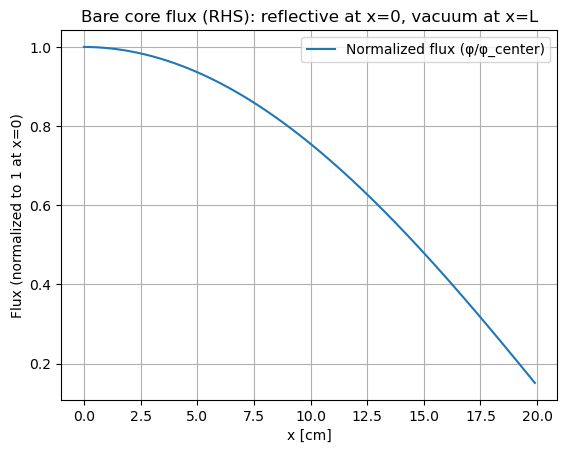

In [2]:
# ============================================
# Q2 — Plot the bare-core flux using Q1 output
# Requires: phi  (flux vector from Q1)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
x = np.arange(N) * dx #N number of cells, dx the size of the cell, defined in the upper code, x is the points where we want to plot the flux

# We normalize the flux at the center (x=0) as we are told
phi_norm = phi / phi[0]

#We plot the flux found in the Q1
plt.figure()
plt.plot(x, phi_norm, label="Normalized flux (φ/φ_center)")
xlabel = "x [cm]" if dx != 1.0 else "Mesh index"
plt.xlabel(xlabel)
plt.ylabel("Flux (normalized to 1 at x=0)")
plt.title("Bare core flux (RHS): reflective at x=0, vacuum at x=L")
plt.grid(True)
plt.legend()
plt.show()


=== k_eff comparison ===
Numerical k_eff  :  0.97147
Analytical k_eff :  0.97356
Abs. difference  : 2.09236e-03
Rel. difference  : 2.14919e-03

=== Net current at core boundary (x = L) ===
Numerical J(L)                       :  7.556621e-02
Analytical J(L)                      :  7.528320e-02
Abs. difference                      : 2.830105e-04


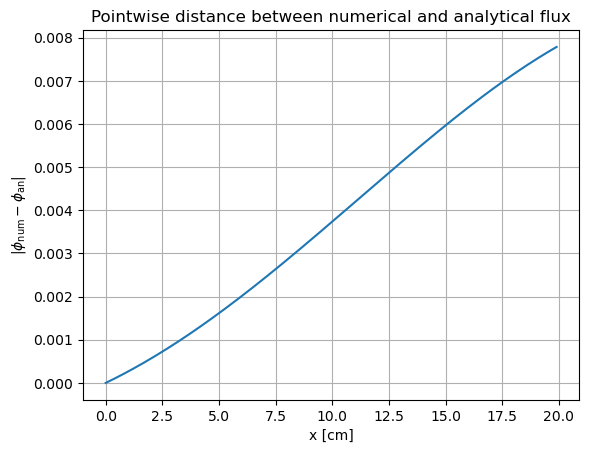

In [3]:
# ============================================================
# Q3 — Compare numerical vs analytical:
#   - k_eff
#   - net current at the core boundary
#   - plot |phi_num - phi_analytical| (both normalized at x=0)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Analytical solution:
# We have, k_eff = k_∞ / (1 + L² B²), B=(π /(H + 2d)),d≈2D, φ(x) = A cos(B x)-->(normalizing at x=0): φ_an(x) = cos(B x).
#Then applying fick's law J(x)=−Ddxdϕ​=DBsin(Bx) we found the current.
# -----------------------------
import math
valor_pi = math.pi
d=2*D
H=2*L
B=(valor_pi)/(H+2*d)                     #H is the lenght of the entire slab, I defined previously L as the lenght of half slab .
phi_an = np.cos(B*x)                     #I put x because we want to compute the flux in the same points as nunmerically.
L2        = D / Sigma_a                  #I have already defined the lenght of the half slab as L, so I define the diffusion lenght as L2.
k_inf     = nuSigma_f / Sigma_a
k_analyt  = k_inf / (1.0 + L2*B**2)      
J_analyt = D * B * np.sin(B * x[-1])    # We could compute J exactly at x = 20 cm, but numerically we do not have the flux there
J_num = J_right                         # because there is no cell centred at x = 20 cm. The last cell is centred at x = 19.9 cm,
                                        # so we will also evaluate the analytical J at this position. Since we are comparing the
                                        # numerical and analytical values, it makes more sense to use the same spatial point.
 





# -----------------------------
# 2) Print comparison
# -----------------------------
print("=== k_eff comparison ===")
print(f"Numerical k_eff  : {k: .5f}")
print(f"Analytical k_eff : {k_analyt: .5f}")
print(f"Abs. difference  : {abs(k - k_analyt):.5e}")
print(f"Rel. difference  : {abs(k - k_analyt)/k_analyt:.5e}")

print("\n=== Net current at core boundary (x = L) ===")
print(f"Numerical J(L)                       : {J_num: .6e}")
print(f"Analytical J(L)                      : {J_analyt: .6e}")
print(f"Abs. difference                      : {abs(J_num - J_analyt):.6e}")

# 3) plot of the pointwise distance between numerical and analytical flux


phi_num = phi_norm


# Absolute difference at each mesh point
eps = np.abs(phi_num - phi_an)

# Plot
plt.figure()
plt.plot(x, eps)
plt.xlabel("x [cm]")
plt.ylabel(r"|$\phi_{\mathrm{num}} - \phi_{\mathrm{an}}$|")
plt.title("Pointwise distance between numerical and analytical flux")
plt.grid(True)
plt.show()


In [4]:
# Q4 — Reflected reactor: report keff (scientific, 5 decimals)
a_core = 20.0   # cm  (half core)
b_refl = 10.0   # cm  (reflector thickness on RHS)
L      = a_core + b_refl
dx     = 0.1
N      = int(L/dx)

i_core_end = int(a_core/dx)  # first reflector cell index

Sigma_a_core, Sigma_s_core, nuSf_core = 0.01, 0.30, 0.015 #We define the scaterring and absortion cross-sections
Sigma_a_refl, Sigma_s_refl, nuSf_refl = 0.01, 0.30, 0.0   #and the source terms in the core and in the reflector

Sigma_a = np.empty(N); Sigma_s = np.empty(N); nuSf = np.empty(N)                                        #We asociate a value of the scaterring and absortion cross-sections
Sigma_a[:i_core_end] = Sigma_a_core; Sigma_s[:i_core_end] = Sigma_s_core; nuSf[:i_core_end] = nuSf_core #and the source term to the central point of each cell
Sigma_a[i_core_end:] = Sigma_a_refl; Sigma_s[i_core_end:] = Sigma_s_refl; nuSf[i_core_end:] = nuSf_refl #the _core terms are asociated to all the cells in the core
                                                                                                        #the _refl terms are asociated to the cells all in the relfector
                                                                                                     

Sigma_t = Sigma_a + Sigma_s
D = 1.0/(3.0*Sigma_t)            #We associate a diffusion coeficient to the central point of each cell

beta = np.zeros(N-1)             
for i in range(N-1):
    Di, Dj = D[i], D[i+1]              #We define Dj as the difussion coeficient from the cell in the position i+1, and Di as the one in i
    beta[i] = 2.0*Di*Dj / (dx*(Di+Dj)) #We define the betha coeficients as (2DiDi+1)/dx(Di+Di+1)

#Build A and F for A φ = (1/k) F φ
    
#Construction of the Matrix A

# We initialize the 3 bands of the matrix A
a_band = np.zeros(N)   # subdiagonal
b_band = np.zeros(N)   # diagonal
c_band = np.zeros(N)   # superdiagonal

for i in range(1, N-1):
    a_band[i] = -beta[i-1]
    b_band[i] =  (beta[i-1] + beta[i] + Sigma_a[i]*dx)
    c_band[i] = -beta[i]
#We apply the BC in the left boundary (reflective)
# a_band[0] = 0
b_band[0] = beta[0] + Sigma_a[0]*dx
c_band[0] = -beta[0]

#We apply the BC in the right boundary (vacuum)
a_band[N-1] = - (2.0*D[N-1] / dx)
b_band[N-1] =   1.0 + (2.0*D[N-1] / dx)
# c_band[N-1] = 0

#Construction of F
F_diag = nuSf * dx

# ---------- Tridiagonal solver ----------

def solve_tridiag(a, b, c, d):
    n = len(b)
    cp = np.zeros(n)
    dp = np.zeros(n)

    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]

    for i in range(1, n):
        denom = b[i] - a[i]*cp[i-1]
        cp[i] = c[i]/denom if i < n-1 else 0.0
        dp[i] = (d[i] - a[i]*dp[i-1]) / denom

    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in range(n-2, -1, -1):
        x[i] = dp[i] - cp[i]*x[i+1]
    return x

# ---------- Power iteration in k ----------

phi_part2    = np.ones(N)
k      = 1.0
tol_k  = 1e-8
tol_phi = 1e-10
max_it = 500

def normalize(v):
    m = np.max(np.abs(v))
    return v if m == 0.0 else v/m

for _ in range(max_it):
    rhs     = (F_diag * phi_part2) / k
    phi_new_part2 = solve_tridiag(a_band, b_band, c_band, rhs)

    num  = np.sum(nuSf * phi_new_part2)
    den  = np.sum(nuSf * phi_part2)
    k_new = k * (num/den) if den != 0.0 else k

    phi_new_part2 = normalize(phi_new_part2)

    dk   = abs(k_new - k)/abs(k_new)
    dphi = np.max(np.abs(phi_new_part2 - phi_part2))

    phi_part2 = phi_new_part2
    k   = k_new

    if dk < tol_k and dphi < tol_phi:
        break

k_eff = k

print(f"k_eff (reflected core) = {k_eff:.5e}")

k_eff (reflected core) = 1.12012e+00


In [5]:
# ---------- Q5: Net current at the core boundary ----------

# Index of the last core cell and first reflector cell
i_core_last  = i_core_end - 1      # last cell in the core
i_refl_first = i_core_end          # first cell in the reflector

# Effective diffusion coefficient at the interface (harmonic average), we are using Di+1/2 = (2·Di·Di+1)/(Di+Di+1)
D_int = 2.0 * D[i_core_last] * D[i_refl_first] / (D[i_core_last] + D[i_refl_first])

# Net current at the core/reflector boundary (x = a_core)
# J > 0 means net current flowing from core into reflector
J_core_boundary = - D_int * (phi_part2[i_refl_first] - phi_part2[i_core_last]) / dx   #we are using the FDM for ∂φ/∂x|_a_core ≈ (φ{i_refl_first} - φ_{i_core_last})/Δx 

print(f"Net current at core boundary J(a_core) = {J_core_boundary:.6e}")


Net current at core boundary J(a_core) = 5.443998e-02


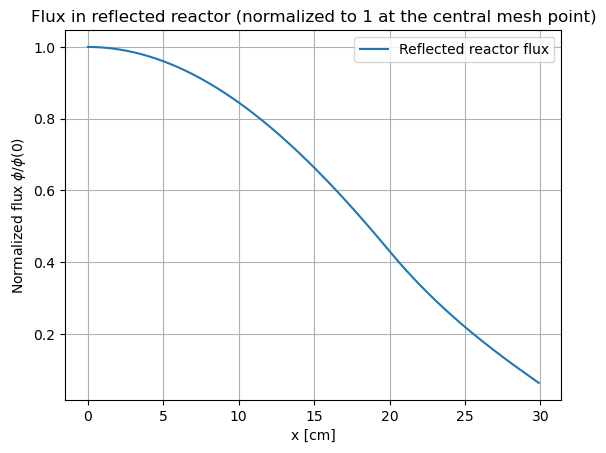

In [6]:
# ==============================================
# Q6 — Plot flux in the reflected reactor
# (normalized to 1 at the central mesh point)
# ==============================================

# 1) Spatial coordinates of cell centers
#    We use the same convention as before: x[i] is the center of cell i.
x = np.arange(N) * dx

# 2) Normalize flux so that phi = 1 at the central mesh point (x ≈ 0)
phi_norm_reflected = phi_part2 / phi_part2[0]

# 3) Plot
plt.figure()
plt.plot(x, phi_norm_reflected, label="Reflected reactor flux")
plt.xlabel("x [cm]")
plt.ylabel(r"Normalized flux $\phi / \phi(0)$")
plt.title("Flux in reflected reactor (normalized to 1 at the central mesh point)")
plt.grid(True)
plt.legend()
plt.show()
